#  Explanatory Analysis Notebook
## Smoking Status Prediction — Key Insights from Data Analysis

This notebook contains only the **crucial final visualizations** selected from the exploratory analysis,
each paired with a written interpretation. It is designed to communicate findings clearly.


## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

# Load the generated dataset (must have run exploratory.ipynb first)
df = pd.read_csv("your_data.csv")
FEATURES    = [c for c in df.columns if c != "smoking"]
num_features = df[FEATURES].select_dtypes(include=np.number).columns.tolist()

print("Dataset shape:", df.shape)
print("Features:", FEATURES)
df.head()


Dataset shape: (159256, 11)
Features: ['eyesight(right)', 'ALT', 'triglyceride', 'fasting blood sugar', 'LDL', 'waist(cm)', 'hearing(right)', 'AST', 'hearing(left)', 'Cholesterol']


,eyesight(right),ALT,triglyceride,fasting blood sugar,LDL,waist(cm),hearing(right),AST,hearing(left),Cholesterol,smoking
0,0.6,25,300,94,75,81.0,1,22,1,172,1
1,0.7,23,55,147,126,89.0,2,27,2,194,0
2,0.5,31,197,79,93,81.0,1,27,1,178,1
3,1.2,27,203,91,102,105.0,1,20,1,180,0
4,1.0,13,87,91,93,80.5,1,19,1,155,1


## Graph 1 — Target Class Distribution
**Question:** Is the dataset balanced between smokers and non-smokers?


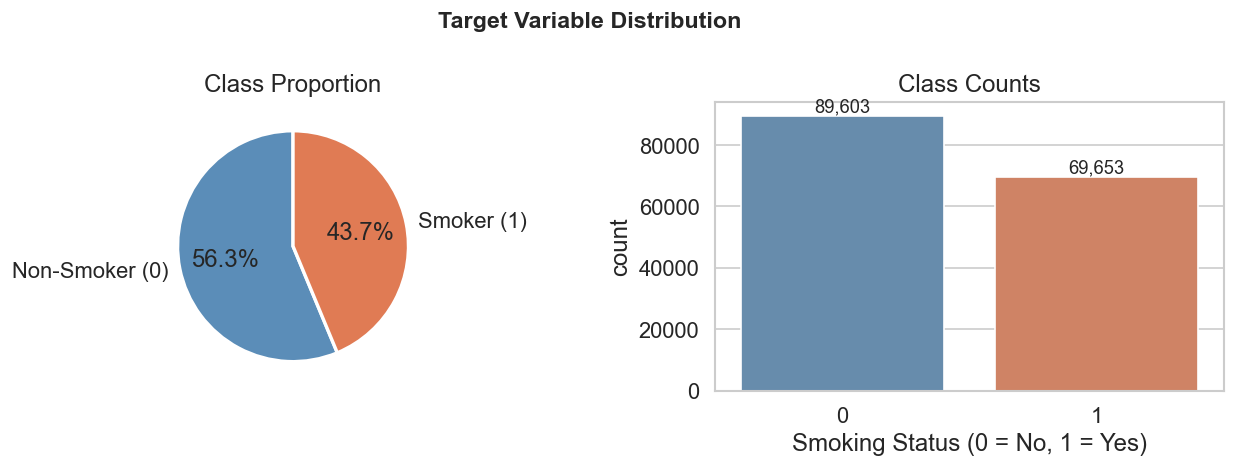

Smokers: 43.7% (69,653)
Non-Smokers: 56.3% (89,603)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
vc = df["smoking"].value_counts()

axes[0].pie(vc, labels=["Non-Smoker (0)", "Smoker (1)"],
            autopct="%1.1f%%", colors=["#5B8DB8","#E07B54"],
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[0].set_title("Class Proportion")

sns.countplot(x="smoking", data=df, palette=["#5B8DB8","#E07B54"], ax=axes[1])
axes[1].set_title("Class Counts")
axes[1].set_xlabel("Smoking Status (0 = No, 1 = Yes)")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=11)

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("explain_fig1_target.png", bbox_inches="tight")
plt.show()
smoker_pct = vc[1] / len(df) * 100
nonsmoker_pct = vc[0] / len(df) * 100
print(f"Smokers: {smoker_pct:.1f}% ({vc[1]:,})")
print(f"Non-Smokers: {nonsmoker_pct:.1f}% ({vc[0]:,})")

**Insight:** *The dataset is reasonably balanced, with 43.7% smokers and 56.3% non-smokers. Since the difference between the two classes is not extreme, the dataset does not suffer from severe class imbalance. Therefore, standard machine learning models can be trained without major bias toward one class, although techniques such as class weighting or SMOTE can still be explored to further improve performance if needed.*


## Graph 2 — Feature Distributions (Histograms + KDE)
**Question:** Which features are normally distributed vs. heavily skewed?


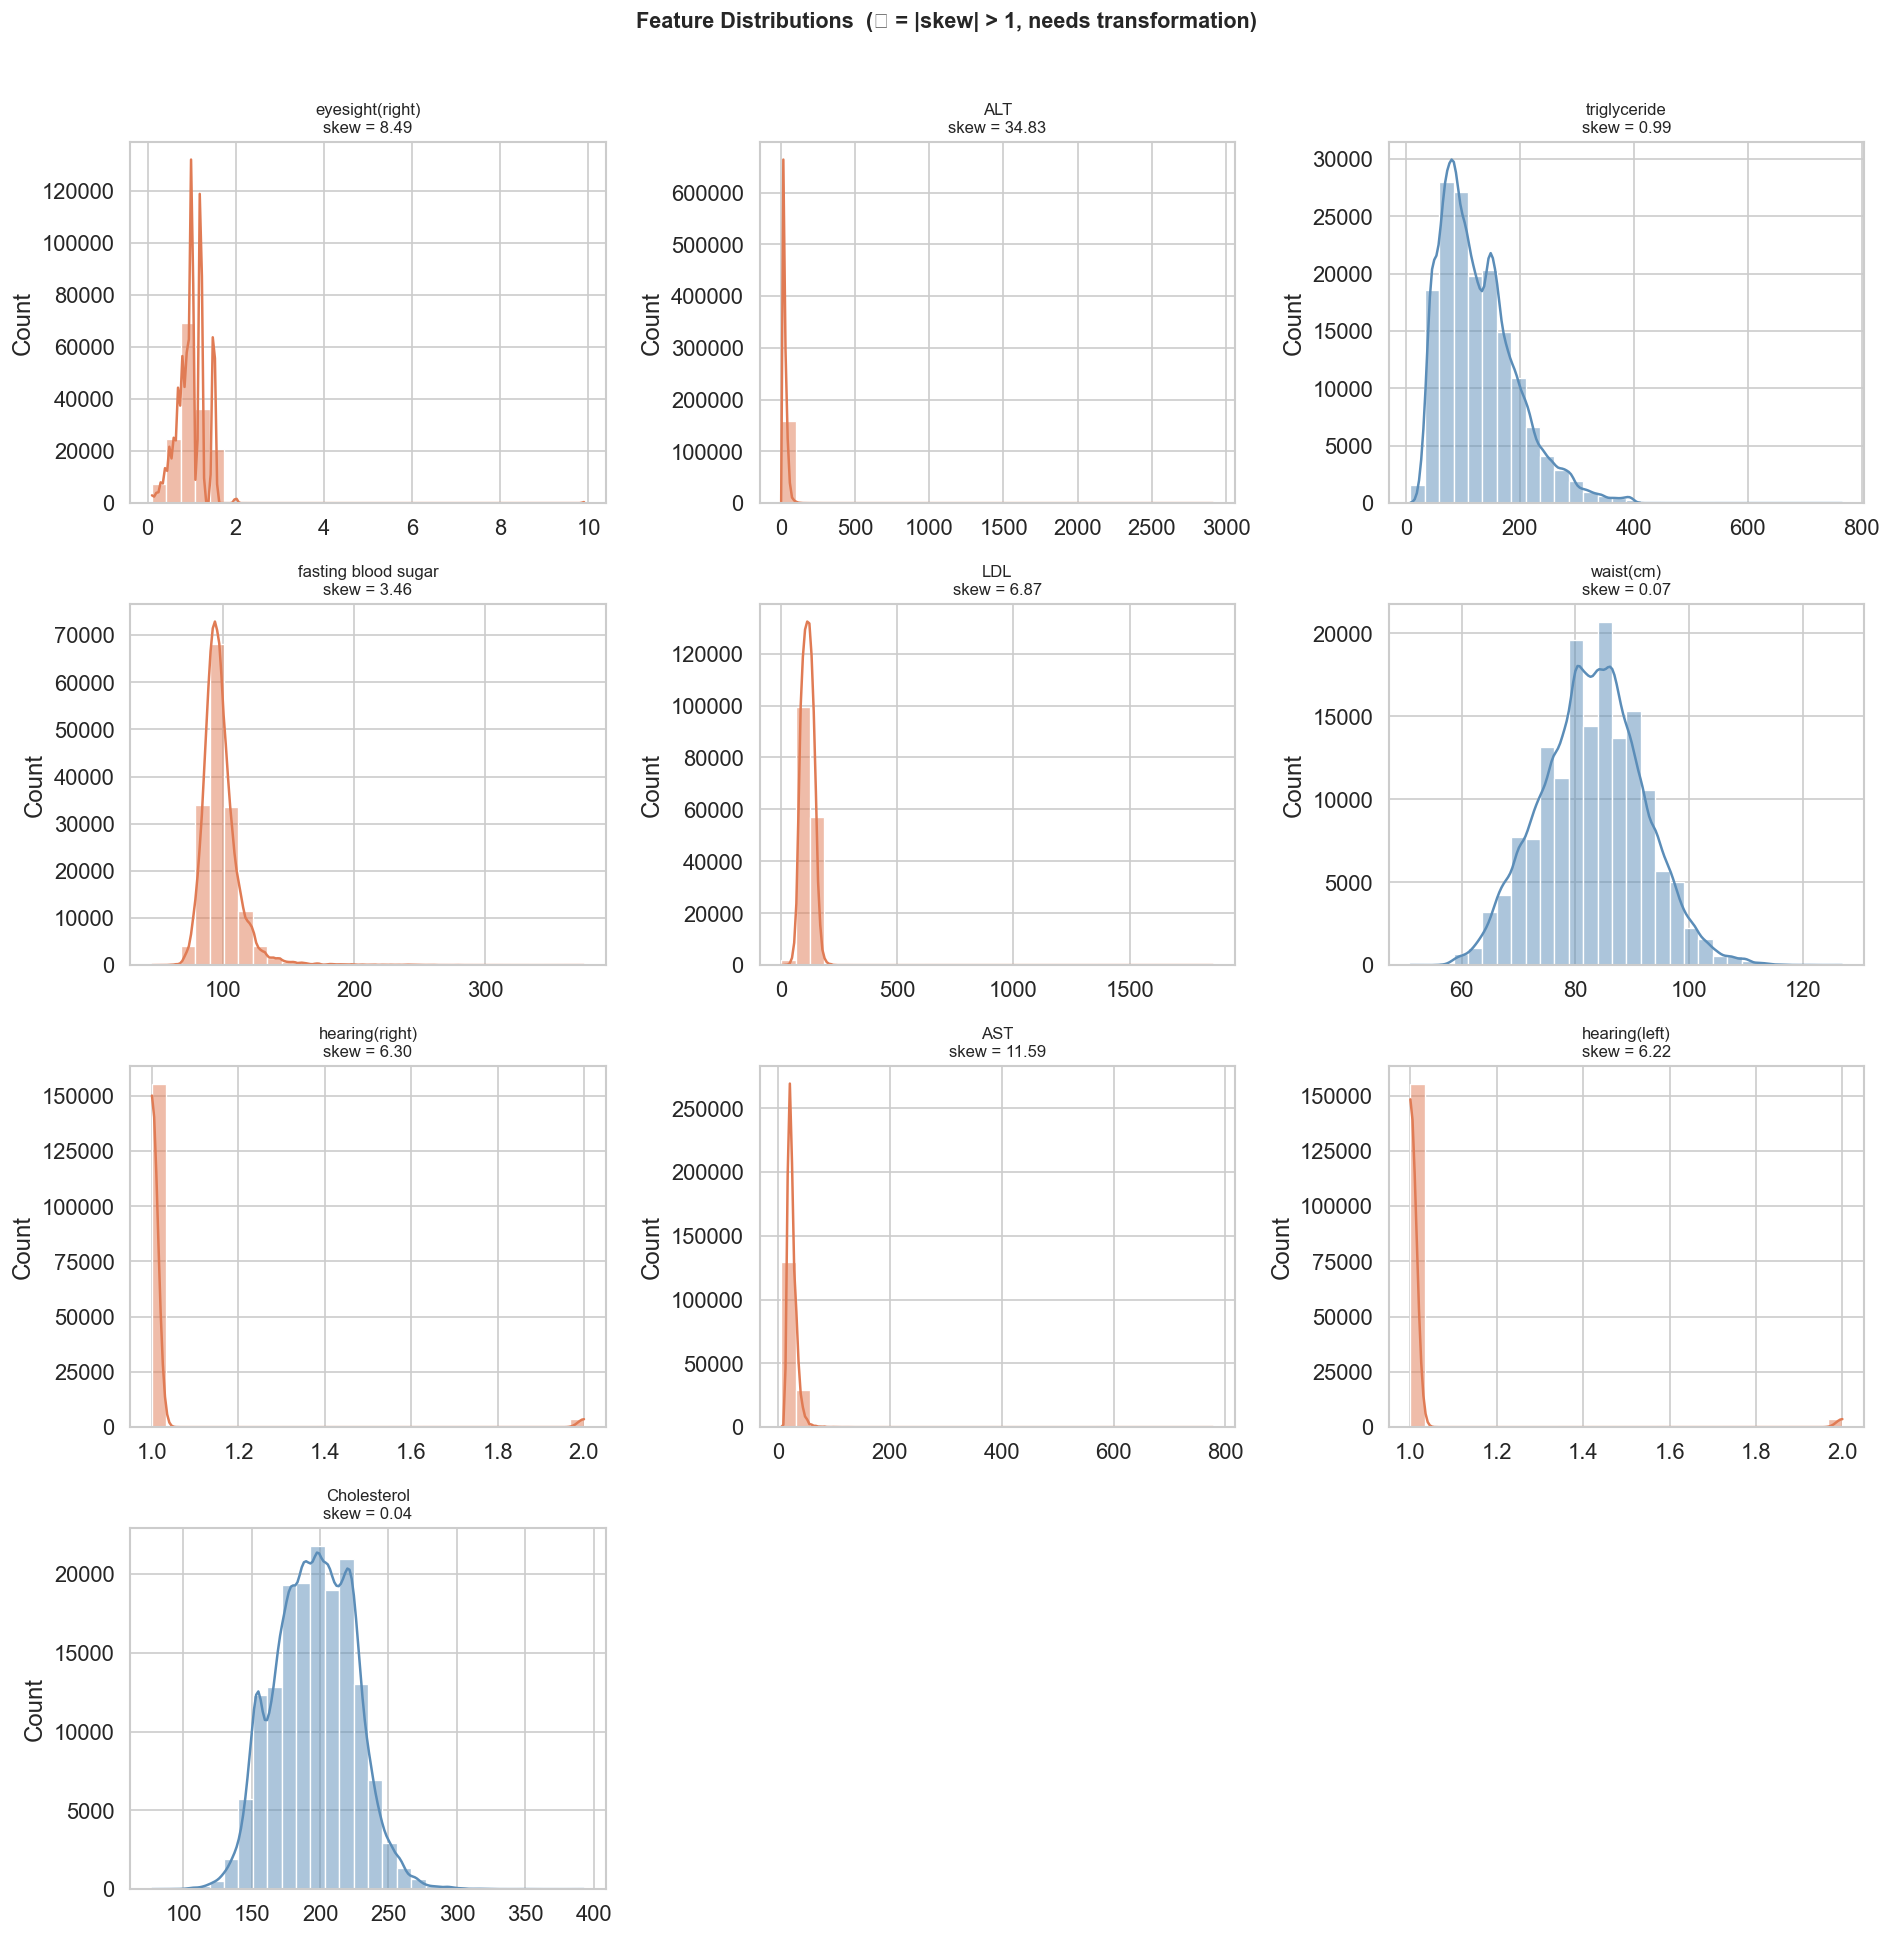

In [4]:
n    = len(num_features)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    skew_val = df[feat].skew()
    color    = "#E07B54" if abs(skew_val) > 1 else "#5B8DB8"
    sns.histplot(df[feat], kde=True, ax=axes[i], color=color, bins=30)
    axes[i].set_title(f"{feat}\nskew = {skew_val:.2f}", fontsize=10)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions  (🟠 = |skew| > 1, needs transformation)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("explain_fig2_distributions.png", bbox_inches="tight")
plt.show()


**Insight:** *Most features approximately follow a normal distribution, especially waist(cm) and eyesight(right). However, features such as triglyceride, ALT, AST, fasting blood sugar, hearing(right), and hearing(left) are highly right-skewed, indicating the presence of extreme values and outliers. These skewed features should be considered for log transformation or robust scaling during preprocessing to improve model performance and reduce sensitivity to outliers*


## Graph 3 — Feature Values by Smoking Status
**Question:** Which features clearly differ between smokers and non-smokers?


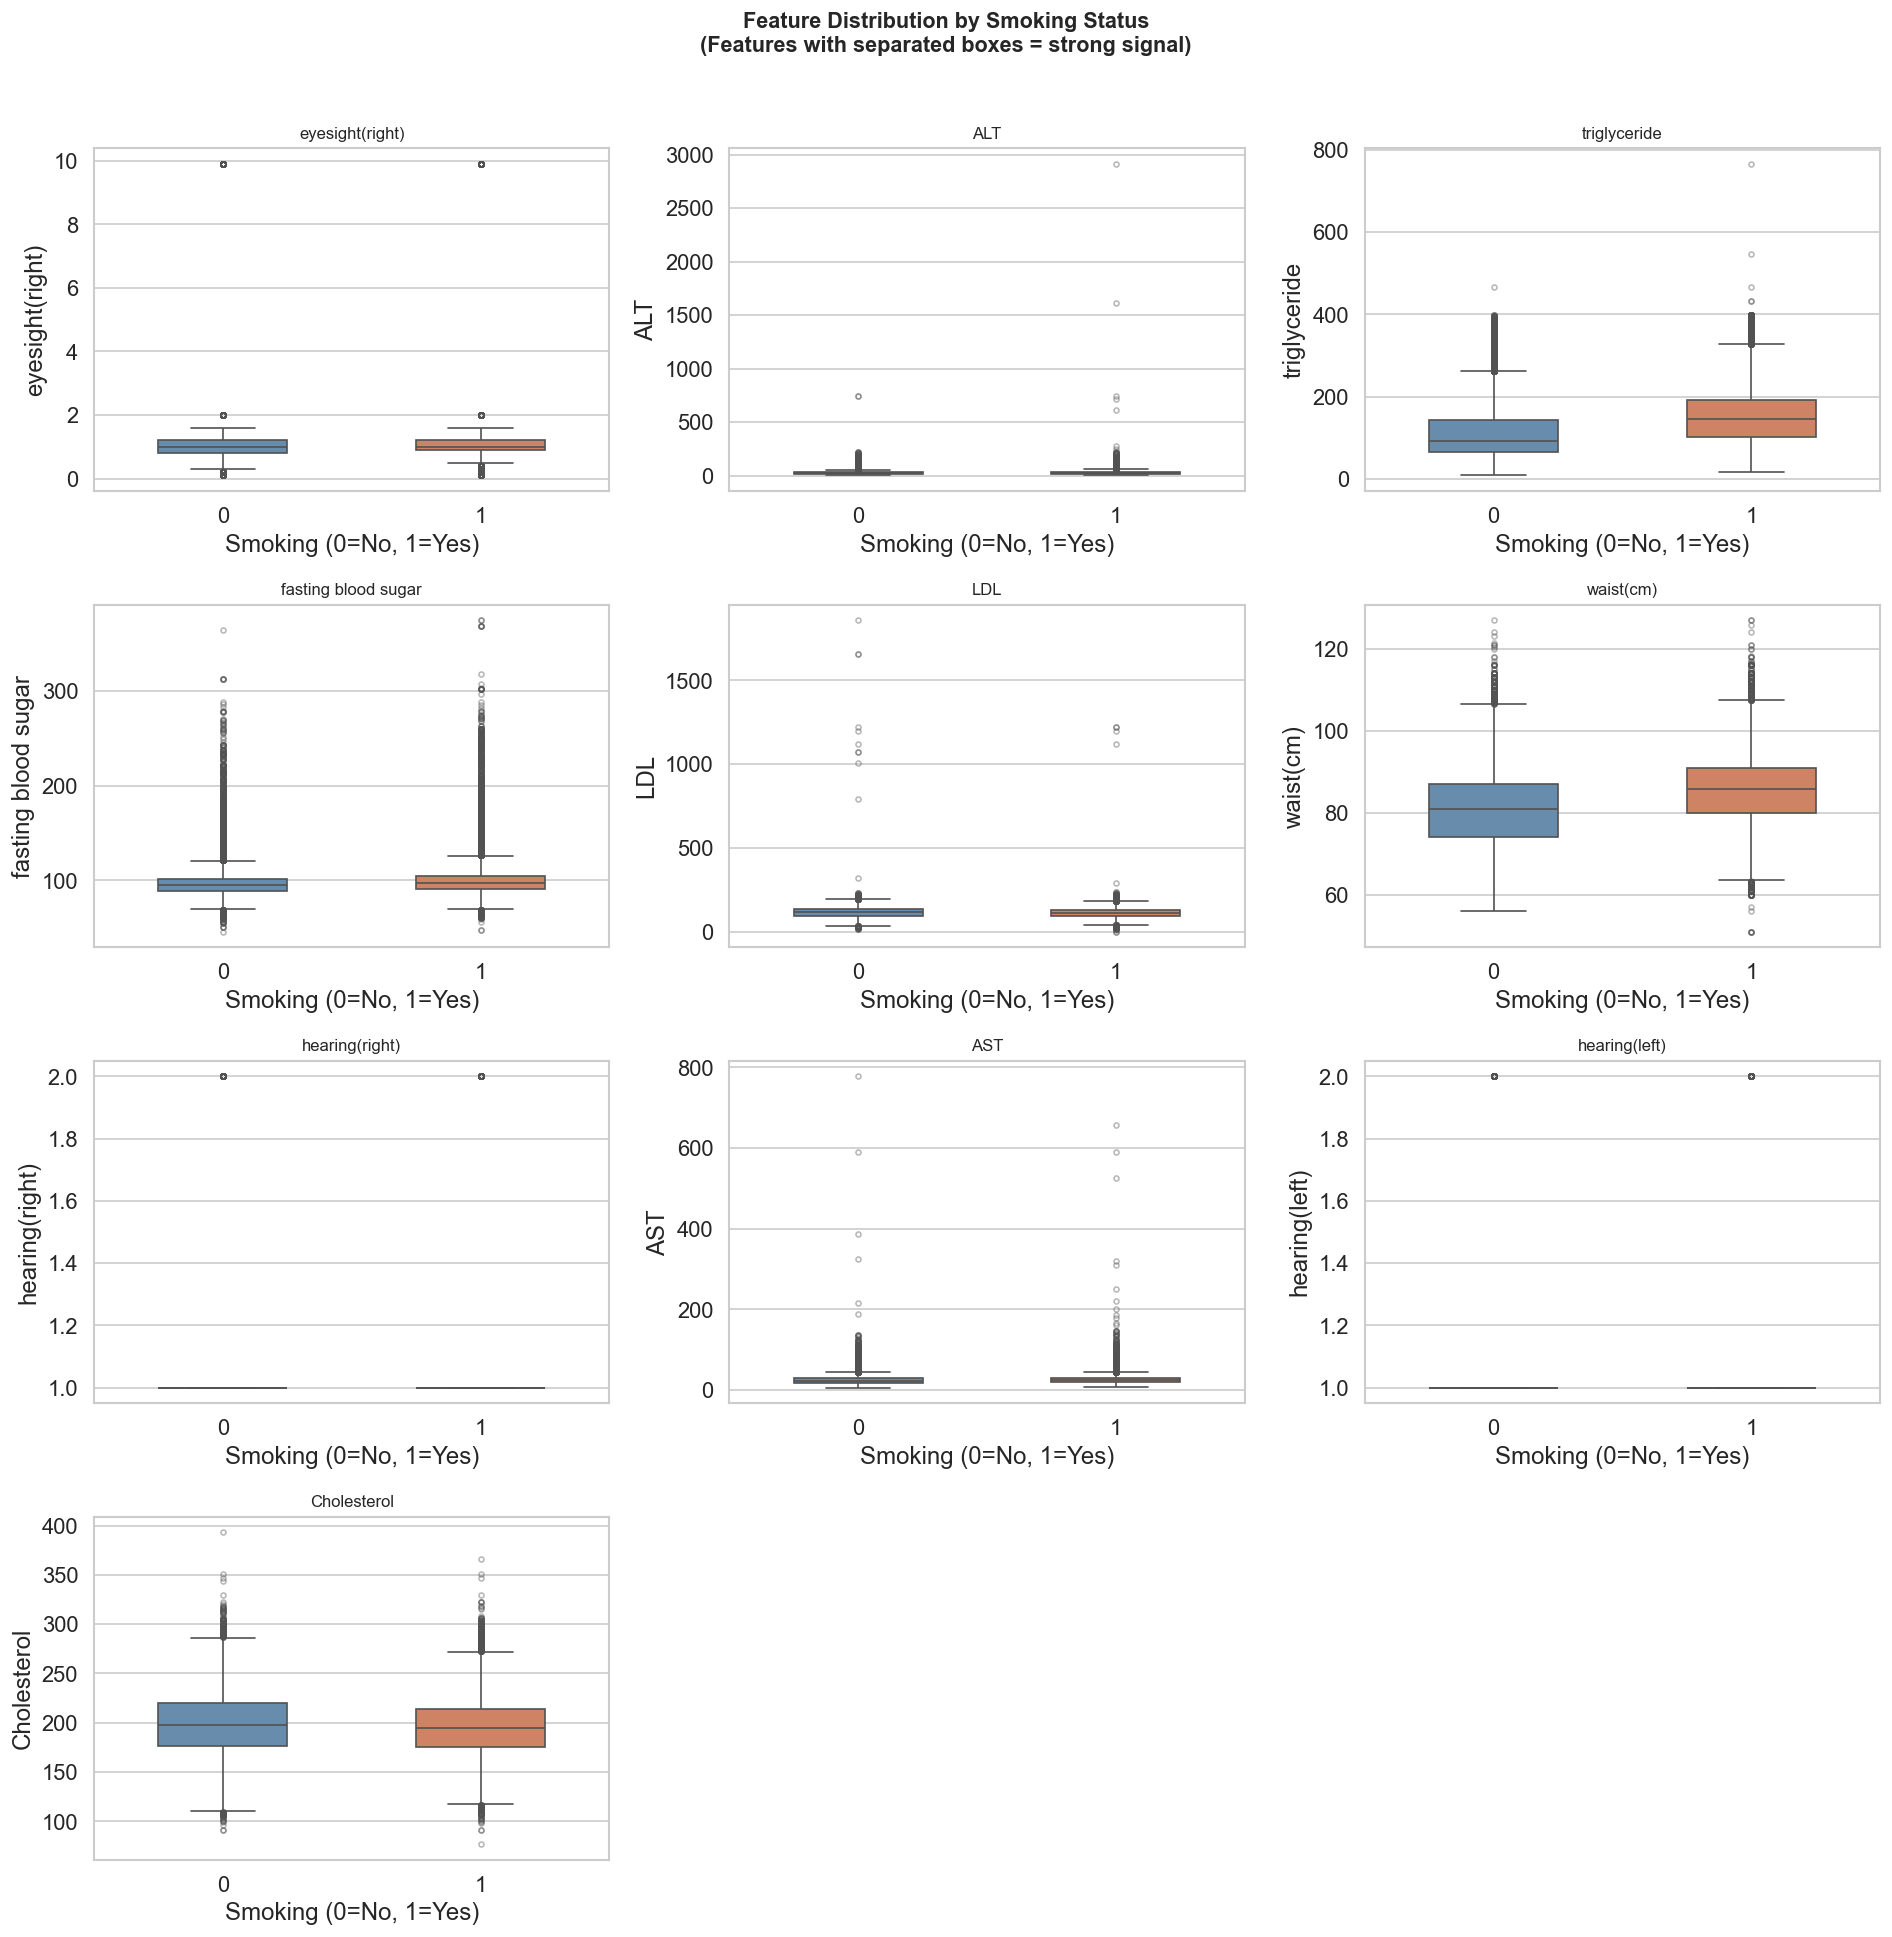

In [5]:
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    sns.boxplot(x="smoking", y=feat, data=df,
                palette=["#5B8DB8","#E07B54"], ax=axes[i],
                width=0.5, flierprops={"marker":"o","markersize":3,"alpha":0.4})
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("Smoking (0=No, 1=Yes)")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distribution by Smoking Status\n(Features with separated boxes = strong signal)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("explain_fig3_boxplots_by_target.png", bbox_inches="tight")
plt.show()


**Insight:** *Several features show noticeable differences between smokers and non-smokers. In particular, triglyceride, waist(cm), fasting blood sugar, and ALT tend to have higher median values among smokers, suggesting a relationship between smoking and metabolic or liver-related health indicators. On the other hand, features such as hearing(left), hearing(right), cholesterol, and LDL show weaker separation between the two groups, indicating lower predictive power individually.*


## Graph 4 — Correlation of Each Feature with Smoking Status
**Question:** Which features are most statistically associated with the target?


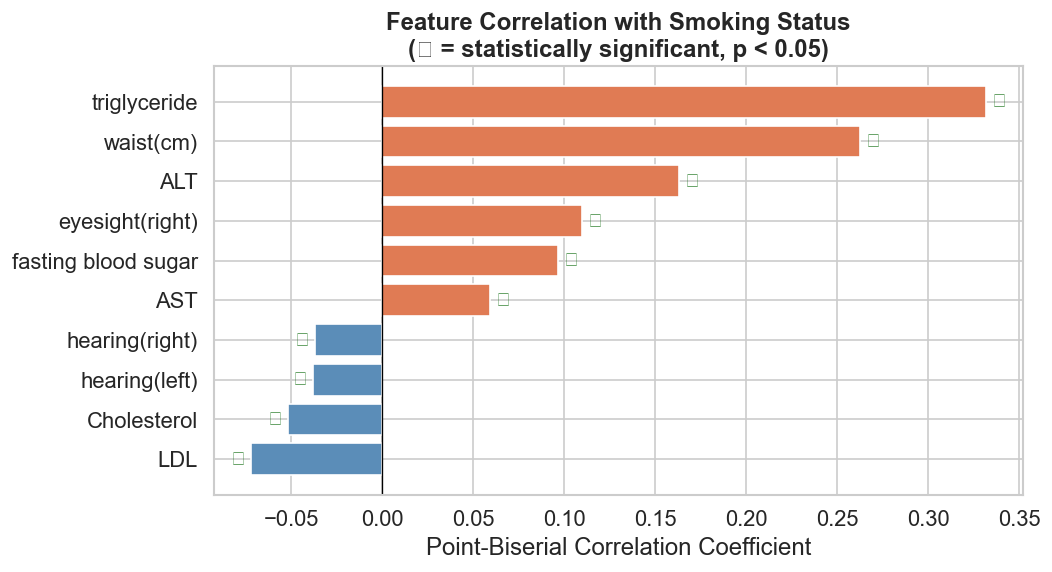


Full correlation table:
                     Correlation p-value Significant
LDL                      -0.0723     0.0        True
Cholesterol              -0.0519     0.0        True
hearing(left)            -0.0382     0.0        True
hearing(right)           -0.0369     0.0        True
AST                       0.0594     0.0        True
fasting blood sugar       0.0965     0.0        True
eyesight(right)           0.1098     0.0        True
ALT                       0.1630     0.0        True
waist(cm)                 0.2627     0.0        True
triglyceride              0.3320     0.0        True


In [6]:
corr_results = {}
for feat in num_features:
    corr, pval = pointbiserialr(df[feat].dropna(),
                                df.loc[df[feat].notna(), "smoking"])
    corr_results[feat] = {"Correlation": round(corr, 4), "p-value": round(pval, 6),
                          "Significant": pval < 0.05}

corr_df = pd.DataFrame(corr_results).T
corr_df["Correlation"] = corr_df["Correlation"].astype(float)
corr_df = corr_df.sort_values("Correlation")

colors = ["#E07B54" if v > 0 else "#5B8DB8" for v in corr_df["Correlation"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corr_df.index, corr_df["Correlation"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)

# Star significance
for bar, (_, row) in zip(bars, corr_df.iterrows()):
    x = bar.get_width()
    label = "★" if row["Significant"] else ""
    ax.text(x + 0.003 if x > 0 else x - 0.003, bar.get_y() + bar.get_height()/2,
            label, va="center", ha="left" if x > 0 else "right",
            fontsize=12, color="darkgreen")

ax.set_xlabel("Point-Biserial Correlation Coefficient")
ax.set_title("Feature Correlation with Smoking Status\n(★ = statistically significant, p < 0.05)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("explain_fig4_correlation_target.png", bbox_inches="tight")
plt.show()

print("\nFull correlation table:")
print(corr_df.to_string())


**Insight:** *The strongest positive correlations with smoking status are observed in triglyceride (r ≈ 0.33) and waist(cm) (r ≈ 0.26), making them the most influential predictors among the selected features. Moderate positive relationships are also present for ALT, fasting blood sugar, and AST. Negative correlations appear for hearing(right), hearing(left), cholesterol, and LDL, although their magnitudes are relatively weak. Most highlighted features are statistically significant (p < 0.05), confirming that they provide meaningful predictive information*


## Graph 5 — Inter-Feature Correlation Heatmap
**Question:** Are any features highly redundant with each other?


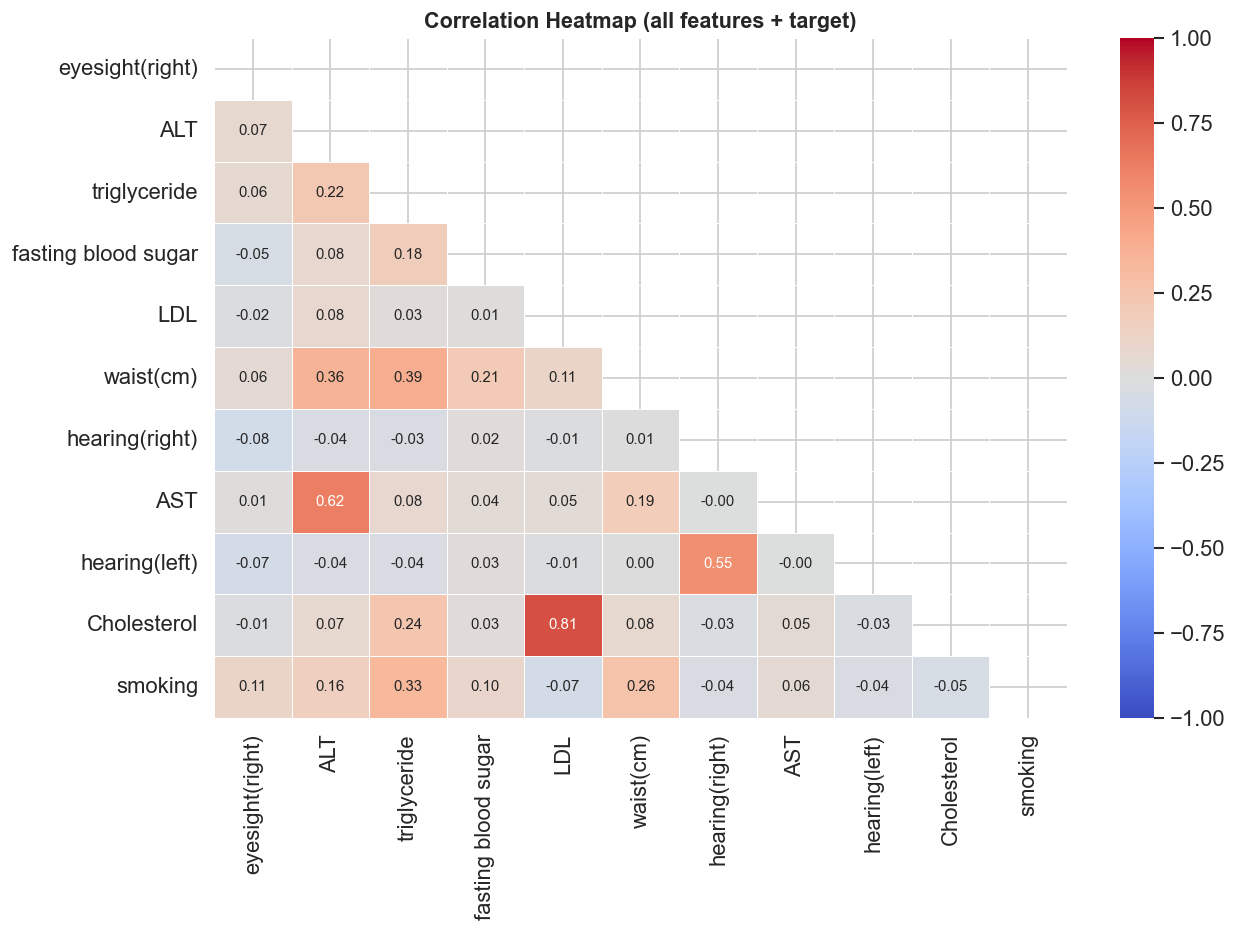

In [7]:
plt.figure(figsize=(11, 8))
corr_matrix = df[num_features + ["smoking"]].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.6, linecolor="white",
            annot_kws={"size": 9})

plt.title("Correlation Heatmap (all features + target)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("explain_fig5_heatmap.png", bbox_inches="tight")
plt.show()


**Insight:** *The heatmap reveals several moderate correlations among features. The strongest relationship exists between hearing(left) and hearing(right), indicating redundancy because both measure similar information. There are also moderate positive correlations between triglyceride and waist(cm), as well as between ALT and AST, which is medically reasonable since both relate to liver function. No extremely high correlations (>0.9) are present, so multicollinearity is limited and most features can still be retained.*


## Graph 6 — PCA 2D Projection
**Question:** Are the two classes (smoker / non-smoker) separable in feature space?


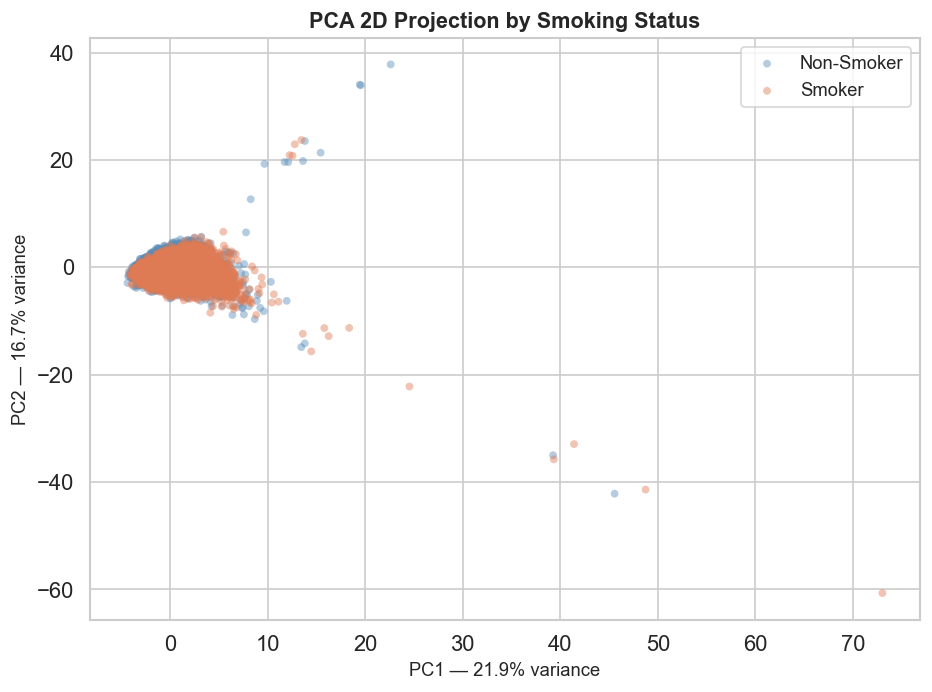

PC1 + PC2 capture 38.6% of total variance.


In [8]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[num_features].fillna(df[num_features].median()))
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, label in [(0,"#5B8DB8","Non-Smoker"), (1,"#E07B54","Smoker")]:
    mask = df["smoking"] == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.45, s=22, color=color, label=label, edgecolors="none")

ax.set_xlabel(f"PC1 — {pca.explained_variance_ratio_[0]*100:.1f}% variance",
              fontsize=11)
ax.set_ylabel(f"PC2 — {pca.explained_variance_ratio_[1]*100:.1f}% variance",
              fontsize=11)
ax.set_title("PCA 2D Projection by Smoking Status", fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("explain_fig6_pca.png", bbox_inches="tight")
plt.show()

total_var = sum(pca.explained_variance_ratio_[:2]) * 100
print(f"PC1 + PC2 capture {total_var:.1f}% of total variance.")


**Insight:** *The PCA visualization shows partial overlap between smokers and non-smokers, meaning the classes are not perfectly separable using only two principal components. However, there is still some visible clustering structure, suggesting that the selected features contain useful predictive information. Since the separation is not linear or fully distinct, more advanced models such as neural networks or ensemble methods may perform better than simple linear approaches alone.*


## Graph 7 — Random Forest Feature Importance
**Question:** Which features are objectively most useful for predicting smoking?


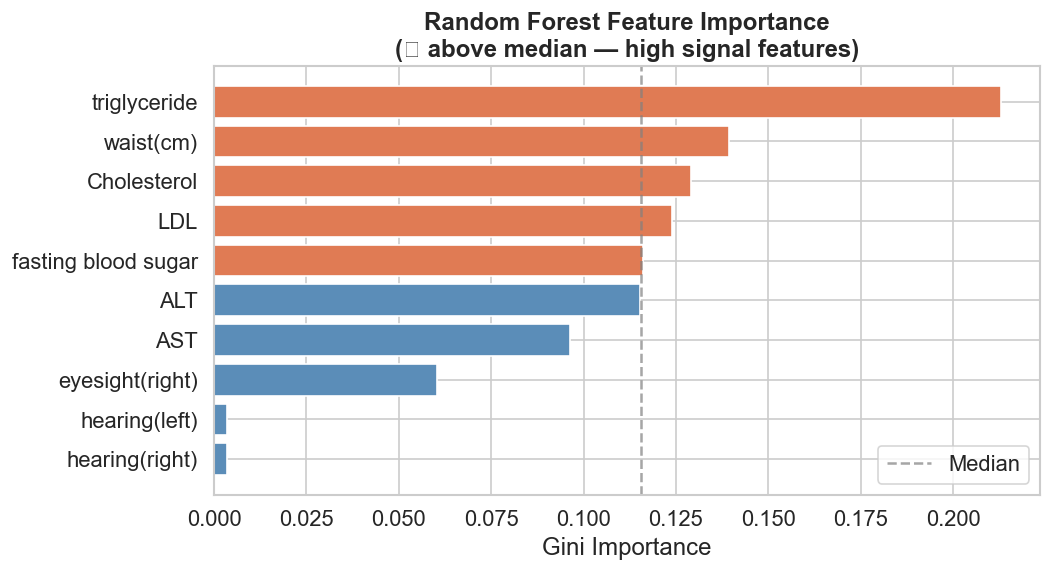


Ranked features:
            Feature  Importance
       triglyceride    0.212878
          waist(cm)    0.139219
        Cholesterol    0.129091
                LDL    0.124008
fasting blood sugar    0.116020
                ALT    0.115189
                AST    0.096330
    eyesight(right)    0.060247
      hearing(left)    0.003571
     hearing(right)    0.003447


In [9]:
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_scaled, df["smoking"])

imp_df = pd.DataFrame({"Feature": num_features,
                        "Importance": rf.feature_importances_}
                       ).sort_values("Importance", ascending=True)

median_imp = imp_df["Importance"].median()
colors     = ["#E07B54" if v > median_imp else "#5B8DB8"
              for v in imp_df["Importance"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df["Feature"], imp_df["Importance"], color=colors, edgecolor="white")
ax.axvline(median_imp, linestyle="--", color="gray", alpha=0.7, label="Median")
ax.set_xlabel("Gini Importance")
ax.set_title("Random Forest Feature Importance\n(🟠 above median — high signal features)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("explain_fig7_rf_importance.png", bbox_inches="tight")
plt.show()

print("\nRanked features:")
print(imp_df.sort_values("Importance", ascending=False).to_string(index=False))


**Insight:** *According to the Random Forest model, triglyceride is the most important feature for predicting smoking status, followed by waist(cm), cholesterol, LDL, and fasting blood sugar. These features contribute the most to classification performance and should be prioritized during feature engineering and model training. Features related to hearing and eyesight contribute less importance, indicating weaker predictive influence compared to metabolic health indicators*


## Summary of Key Findings

| # | Finding | Implication for Feature Engineering |
|---|---------|--------------------------------------|
| 1 | The dataset is reasonably balanced between smokers and non-smokers | No severe class imbalance handling is required, although class weighting may still improve performance |
| 2 | Triglyceride, waist(cm), fasting blood sugar, and ALT are the strongest predictors of smoking status | These features should be prioritised during model training and retained during feature selection |
| 3 | Several features such as triglyceride, ALT, AST, and fasting blood sugar are highly right-skewed | Apply log transformation or robust scaling to reduce skewness and improve model stability |
| 4 | Multiple features contain extreme outliers | Apply IQR-based outlier removal or robust preprocessing techniques |
| 5 | Some feature pairs such as hearing(left)/hearing(right) and ALT/AST are moderately correlated | Consider feature selection or dimensionality reduction to reduce redundancy |
| 6 | PCA analysis shows partial overlap between smokers and non-smokers | Linear models may achieve moderate performance, while non-linear models may capture patterns more effectively |

---

# Final Conclusion

The explanatory analysis revealed that metabolic and liver-related measurements
such as triglyceride, waist circumference, fasting blood sugar, ALT, and AST
show the strongest relationship with smoking status.

Several features contain skewness and outliers, making preprocessing steps such
as normalization, robust scaling, and outlier removal necessary before model training.

The PCA analysis demonstrated partial overlap between smokers and non-smokers,
suggesting that smoking behavior cannot be separated perfectly using simple
linear boundaries alone. Therefore, more advanced machine learning models,
including neural networks and ensemble approaches, are expected to achieve
better predictive performance.

The dataset will later be divided into training, validation, and testing subsets
to ensure fair model evaluation, avoid data leakage, and accurately measure
generalization performance on unseen data.